# Positioning task #1



## Introduction

In this tutorial, we will explore a common failure in machine learning: the task of object positioning using Convolutional Neural Networks (CNNs). Although this is a very common task, we will see that our training procedure ultimately fails. We invite you to solve the issue in the training process!

In [5]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL']='2'  # suppress TensorFlow warnings
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"  # use CPU only, uncomment this line to use GPU

import matplotlib.pyplot as plt
import numpy as np
import torch # import torch to make tensorflow-gpu available (don't know why)
import tensorflow as tf
# fix random seed for reproducibility
seed = 0
tf.random.set_seed(seed)
np.random.seed(seed)

In [6]:
tf.test.is_gpu_available()

True

2024-04-25 13:31:19.743117: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-04-25 13:31:19.743316: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2024-04-25 13:31:19.743429: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

## Load dataset

First, we will load a prepared dataset that includes both training and test data.

In [7]:
def load_data(train_data_path, test_data_path):
    traindata = np.load(train_data_path)
    testdata = np.load(test_data_path)
    X_train = traindata['img']
    y_train = traindata['position']
    X_test = testdata['img']
    y_test = testdata['position']
    return (X_train, y_train), (X_test, y_test)

As the image dataset is in 8-bit unsigned integer format (`uint8`, with values ranging from 0 to 255), it is necessary to convert it to `float32` by normalizing the values. This conversion allows neural networks to process the data.

This time, `X_train` and `X_test` are images and `y_train` and `y_test` are positions of the shapes. 

In [8]:
label_name = ['circle', 'triangle', 'square']
(X_train, y_train), (X_test, y_test) = load_data('../data/positioning_1_train.npz', '../data/positioning_test.npz')

# normalize image data (uint8 [0-255] -> float32 [0.0-1.0])
X_train = (X_train / 255).astype(np.float32)
X_test = (X_test / 255.).astype(np.float32)

Let's examine the size of the loaded dataset.

In [9]:
print('X_train.shape: ', X_train.shape)
print('Y_train.shape: ', y_train.shape)
print('X_test.shape:  ', X_test.shape)
print('Y_test.shape:  ', y_test.shape)

X_train.shape:  (60000, 36, 36, 3)
Y_train.shape:  (60000, 2)
X_test.shape:   (10000, 36, 36, 3)
Y_test.shape:   (10000, 2)


Additionally, let's inspect the images in the loaded dataset. To achieve this, we will display the first 36 images along with their positions from both the training and test data.

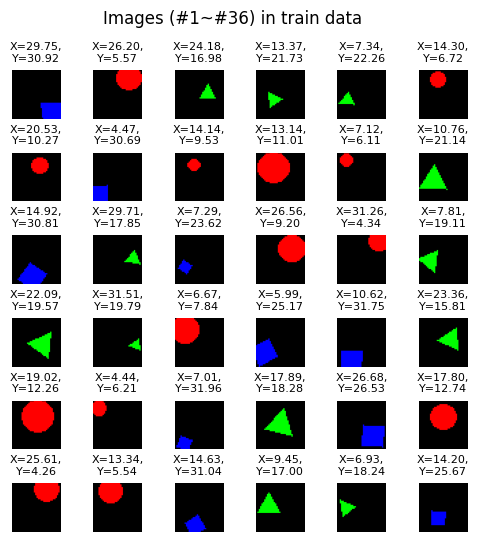

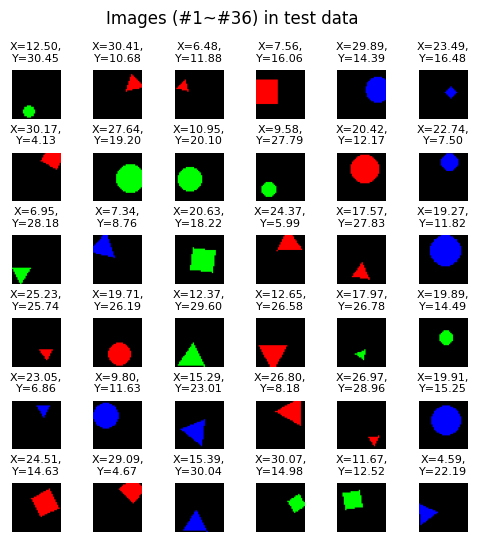

In [10]:
def plot_image(X, y):
    plt.figure(figsize=(6,6))
    for i in range(6*6):
        plt.subplot(6,6,i+1)
        plt.imshow(X[i], cmap='gray')  # cmap='gray' displays an image in black and white for monotone images and in color for rgb images. 
        plt.axis('off')
        plt.title(f'X={y[i][0]:.2f},\nY={y[i][1]:.2f}', fontsize=8) # Top left is (0,0)
    plt.subplots_adjust(wspace=0.4, hspace=0.7)

plot_image(X_train, y_train)
plt.suptitle('Images (#1~#36) in train data')
plt.show()

plot_image(X_test, y_test)
plt.suptitle('Images (#1~#36) in test data')
plt.show()

Our goal is to train the neural network model to predict the positions of the shapes (circles, triangles, and squares) in the images.

## Define the model
The next step is to define our neural network model. To create a CNN model for positioning tasks, we need to set up the model to be suitable for the size of the processed images, including their height, width, and the number of channels (e.g., RGB), as well as the coordinates of the shapes. 

In [11]:
img_rows, img_cols, img_channel = X_train.shape[1:4] # size of height, width, channels
num_axis = 2 # number of axis for positioning

With those necessary numbers, finally we can define our CNN model. 

In [14]:
def get_model(input_shape, num_axis):
    model = tf.keras.Sequential([
            tf.keras.layers.Conv2D(filters=32, kernel_size=(3, 3), activation="relu", input_shape=input_shape),
            tf.keras.layers.MaxPooling2D(pool_size=(2, 2)),
            tf.keras.layers.Flatten(),
            tf.keras.layers.Dense(128, activation="relu"),
            tf.keras.layers.Dense(num_axis, activation="linear"),
        ])
    return model

model = get_model(input_shape=(img_rows, img_cols, img_channel), num_axis=num_axis)
model.compile(optimizer=tf.keras.optimizers.Adadelta(),
              loss='mean_squared_error',
              metrics=['mean_absolute_error'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 34, 34, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 17, 17, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,183,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185,026 (4.52 MB)

 Trainable params: 1,185,026 (4.52 MB)

 Non-trainable params: 0 (0.00 B)

## Training

Now let's train our model with the loaded images!

In [ ]:
epochs = 10
batch_size = 32
result = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size)

print(f'train loss: {result.history["loss"][-1]}, train error: {result.history["mean_absolute_error"][-1]} pixels')

## Problem

The error in prediction on the training data is much small.
Then, let's evaluate it using the test data.

In [ ]:
test_loss, test_metric = model.evaluate(X_test, y_test)
print(f'test loss: {test_loss}, test error: {test_metric} pixels')

313/313 [==============================] - 0s 1ms/step - loss: 18.6783 - mean_absolute_error: 3.1275
test loss: 18.67831802368164, test error: 3.127547264099121 pixels


The error in the test data is much higher. 
This suggests that generalization is not working well.
Let's consider the reasons for such results and find a solution to achieve high performance on test data.